In [24]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

zip_path = "/content/drive/MyDrive/FarmSight/datasets/paddy/train_images.zip"

print("ZIP exists:", os.path.exists(zip_path))
print("ZIP path:", zip_path)

ZIP exists: True
ZIP path: /content/drive/MyDrive/FarmSight/datasets/paddy/train_images.zip


In [3]:
import os

os.makedirs(
    "/content/drive/MyDrive/FarmSight/models",
    exist_ok=True
)

print("Model folder ready")

Model folder ready


In [4]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/FarmSight/datasets/paddy/train_images.zip"
extract_path = "/content/paddy_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
import os
from pathlib import Path

DATASET_PATH = Path("/content/paddy_dataset")

print("Checking dataset folders...\n")

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(str(DATASET_PATH), "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        continue

Checking dataset folders...

paddy_dataset/
  bacterial_panicle_blight/
  blast/
  brown_spot/
  tungro/
  bacterial_leaf_blight/
  bacterial_leaf_streak/
  dead_heart/
  downy_mildew/
  normal/
  hispa/


In [6]:
from pathlib import Path

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

dataset_root = Path("/content/paddy_dataset")

class_counts = {}

for class_dir in dataset_root.rglob("*"):
    if class_dir.is_dir():
        images = [
            f for f in class_dir.iterdir()
            if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
        ]

        if images:
            class_counts[class_dir.name] = len(images)

print("Class distribution:\n")

total_images = 0

for class_name, count in sorted(class_counts.items()):
    print(f"{class_name:30s} : {count}")
    total_images += count

print("\nTotal images:", total_images)
print("Total classes:", len(class_counts))

Class distribution:

bacterial_leaf_blight          : 479
bacterial_leaf_streak          : 380
bacterial_panicle_blight       : 337
blast                          : 1738
brown_spot                     : 965
dead_heart                     : 1442
downy_mildew                   : 620
hispa                          : 1594
normal                         : 1764
tungro                         : 1088

Total images: 10407
Total classes: 10


In [7]:
from PIL import Image
from pathlib import Path

dataset_root = Path("/content/paddy_dataset")

bad_files = []

for image_path in dataset_root.rglob("*"):
    if image_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
        try:
            with Image.open(image_path) as img:
                img.verify()
        except Exception:
            bad_files.append(str(image_path))

print("Corrupt images:", len(bad_files))

if bad_files:
    print("\nSample corrupt files:")
    for file in bad_files[:10]:
        print(file)

Corrupt images: 0


In [8]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

dataset_root = Path("/content/paddy_dataset")

records = []

for class_dir in dataset_root.rglob("*"):
    if class_dir.is_dir():
        for img_path in class_dir.iterdir():
            if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                records.append({
                    "filepath": str(img_path),
                    "label": class_dir.name
                })

df = pd.DataFrame(records)

print("Total images:", len(df))
print("Classes:", df["label"].nunique())

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("\nTrain:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Total images: 10407
Classes: 10

Train: 7284
Validation: 1561
Test: 1562


In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = 10
SEED = 42

In [12]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

In [13]:
class_names = sorted(df["label"].unique().tolist())

print("Class names:")
for i, name in enumerate(class_names):
    print(i, name)

class_to_index = {name: i for i, name in enumerate(class_names)}

Class names:
0 bacterial_leaf_blight
1 bacterial_leaf_streak
2 bacterial_panicle_blight
3 blast
4 brown_spot
5 dead_heart
6 downy_mildew
7 hispa
8 normal
9 tungro


In [14]:
def make_dataset(dataframe, training=False):
    paths = dataframe["filepath"].values
    labels = dataframe["label"].map(class_to_index).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    ds = ds.map(
        load_and_preprocess,
        num_parallel_calls=2
    )

    if training:
        ds = ds.shuffle(
            buffer_size=2048,
            seed=SEED
        )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(1)

    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

In [15]:
checkpoint_path = "/content/drive/MyDrive/FarmSight/models/best_paddy_mobilenetv2.keras"

model = tf.keras.models.load_model(checkpoint_path)

print("Best Stage-1 model loaded successfully!")

Best Stage-1 model loaded successfully!


In [16]:
model.evaluate(val_ds)

98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.4504 - loss: 1.6785


[1.678477168083191, 0.45035234093666077]

In [17]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Sample labels:", labels[:10].numpy())

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Sample labels: [9 9 7 8 9 0 5 5 8 5]


In [18]:
base_model = model.get_layer("mobilenetv2_1.00_224")

base_model.trainable = True

# Keep most MobileNetV2 layers frozen.
# Fine-tune only the last 30 layers.
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Total base model layers:", len(base_model.layers))
print(
    "Trainable base model layers:",
    sum(layer.trainable for layer in base_model.layers)
)

Total base model layers: 154
Trainable base model layers: 30


In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
fine_tune_checkpoint = "/content/drive/MyDrive/FarmSight/models/best_paddy_finetuned.keras"

fine_tune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        fine_tune_checkpoint,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )
]

In [21]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=fine_tune_callbacks
)

Epoch 1/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.3952 - loss: 1.8670
Epoch 1: val_loss improved from None to 1.68638, saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_finetuned.keras
456/456 ━━━━━━━━━━━━━━━━━━━━ 60s 91ms/step - accuracy: 0.4522 - loss: 1.6374 - val_accuracy: 0.4452 - val_loss: 1.6864 - learning_rate: 1.0000e-05
Epoch 2/5
455/456 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5168 - loss: 1.3892
Epoch 2: val_loss did not improve from 1.68638
456/456 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - accuracy: 0.5342 - loss: 1.3470 - val_accuracy: 0.4375 - val_loss: 1.7229 - learning_rate: 1.0000e-05
Epoch 3/5
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5595 - loss: 1.2721
Epoch 3: val_loss improved from 1.68638 to 1.64114, saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_finetuned.keras

Epoch 3: finished saving model 

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
continued_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=fine_tune_callbacks
)

Epoch 1/3
455/456 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6714 - loss: 0.9804
Epoch 1: val_loss improved from 1.56436 to 1.55981, saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_finetuned.keras
456/456 ━━━━━━━━━━━━━━━━━━━━ 49s 76ms/step - accuracy: 0.6658 - loss: 0.9932 - val_accuracy: 0.4862 - val_loss: 1.5598 - learning_rate: 5.0000e-06
Epoch 2/3
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6799 - loss: 0.9588
Epoch 2: val_loss did not improve from 1.55981
456/456 ━━━━━━━━━━━━━━━━━━━━ 36s 69ms/step - accuracy: 0.6826 - loss: 0.9583 - val_accuracy: 0.4875 - val_loss: 1.5605 - learning_rate: 5.0000e-06
Epoch 3/3
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6691 - loss: 0.9497
Epoch 3: val_loss improved from 1.55981 to 1.55948, saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_finetuned.keras

Epoch 3: finished saving mod

In [25]:
import tensorflow as tf

final_model_path = "/content/drive/MyDrive/FarmSight/models/best_paddy_finetuned.keras"

model = tf.keras.models.load_model(final_model_path)

print("Final model loaded successfully!")

Final model loaded successfully!


In [26]:
train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

In [27]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.4718 - loss: 1.6206
Test Loss: 1.620571255683899
Test Accuracy: 0.47183099389076233


In [28]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions completed!")
print("Test samples:", len(y_true))

Predictions completed!
Test samples: 1562


In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

                          precision    recall  f1-score   support

   bacterial_leaf_blight     0.1921    0.5417    0.2836        72
   bacterial_leaf_streak     0.5000    0.0526    0.0952        57
bacterial_panicle_blight     0.8667    0.2600    0.4000        50
                   blast     0.4548    0.5594    0.5017       261
              brown_spot     0.5745    0.1862    0.2812       145
              dead_heart     0.8364    0.6359    0.7225       217
            downy_mildew     0.5814    0.2688    0.3676        93
                   hispa     0.4821    0.4519    0.4665       239
                  normal     0.4884    0.6340    0.5517       265
                  tungro     0.3608    0.4294    0.3922       163

                accuracy                         0.4718      1562
               macro avg     0.5337    0.4020    0.4062      1562
            weighted avg     0.5293    0.4718    0.4675      1562



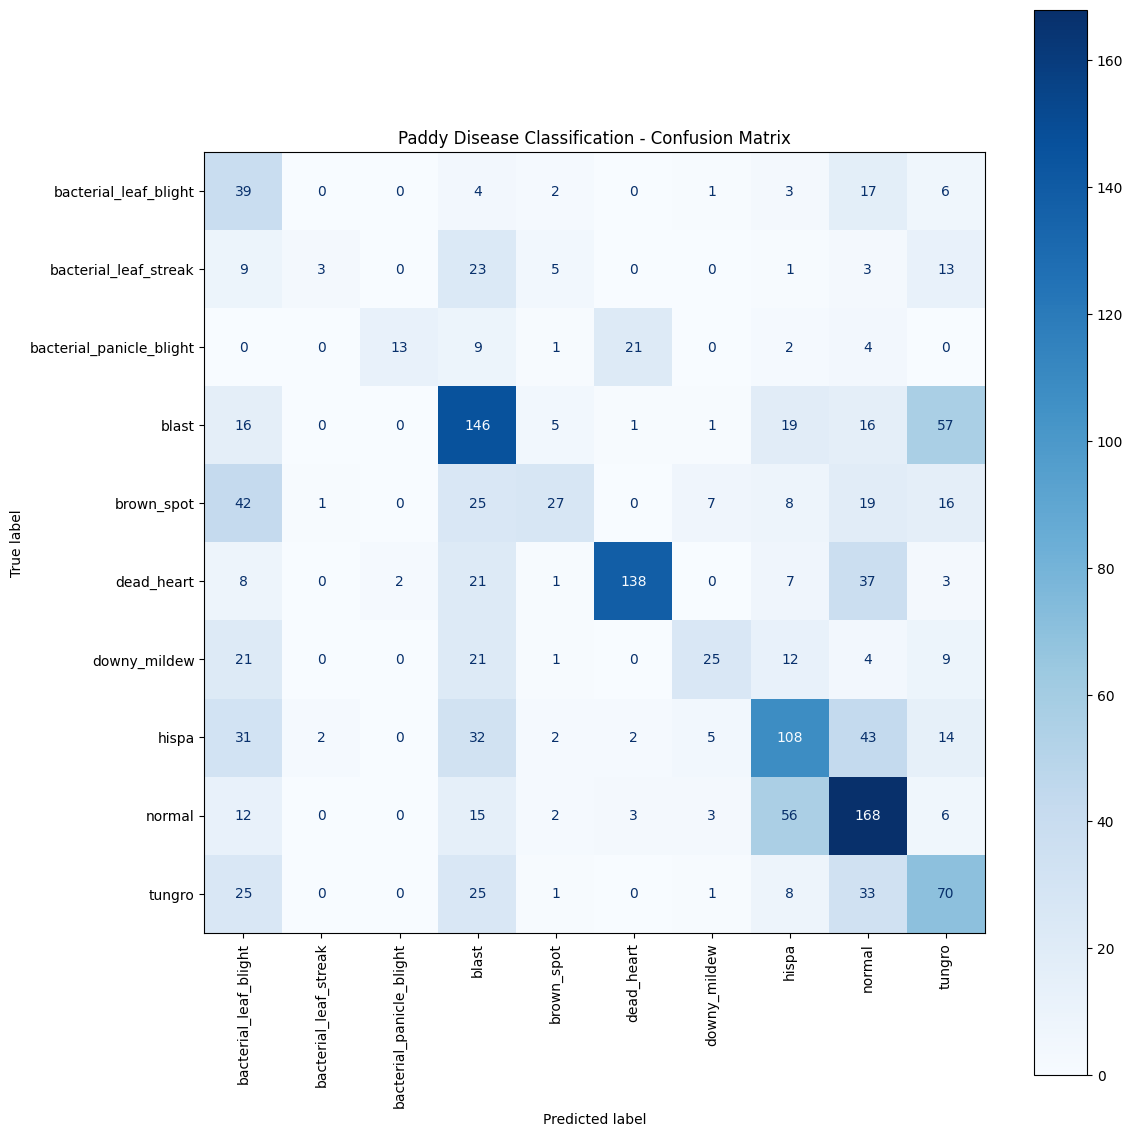

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    values_format="d"
)

plt.title("Paddy Disease Classification - Confusion Matrix")
plt.tight_layout()
plt.show()

In [31]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

train_labels = train_df["label"].map(class_to_index).values

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(class_names)),
    y=train_labels
)

class_weights = {
    i: float(weight)
    for i, weight in enumerate(weights)
}

print("Class weights:\n")

for i, weight in class_weights.items():
    print(f"{i} {class_names[i]:30s}: {weight:.4f}")

Class weights:

0 bacterial_leaf_blight         : 2.1743
1 bacterial_leaf_streak         : 2.7383
2 bacterial_panicle_blight      : 3.0864
3 blast                         : 0.5990
4 brown_spot                    : 1.0791
5 dead_heart                    : 0.7219
6 downy_mildew                  : 1.6783
7 hispa                         : 0.6527
8 normal                        : 0.5898
9 tungro                        : 0.9559


In [32]:
final_model_path = "/content/drive/MyDrive/FarmSight/models/best_paddy_finetuned.keras"

model = tf.keras.models.load_model(final_model_path)

print("Best fine-tuned model loaded!")

Best fine-tuned model loaded!


In [33]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [34]:
weighted_checkpoint = "/content/drive/MyDrive/FarmSight/models/best_paddy_weighted.keras"

weighted_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        weighted_checkpoint,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=1,
        min_lr=1e-7
    )
]

In [35]:
weighted_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    class_weight=class_weights,
    callbacks=weighted_callbacks
)

Epoch 1/3
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6910 - loss: 1.0032
Epoch 1: val_loss improved from None to 1.57301, saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_weighted.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_weighted.keras
456/456 ━━━━━━━━━━━━━━━━━━━━ 60s 90ms/step - accuracy: 0.6915 - loss: 0.9852 - val_accuracy: 0.4965 - val_loss: 1.5730 - learning_rate: 2.0000e-06
Epoch 2/3
455/456 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6863 - loss: 0.9714
Epoch 2: val_loss did not improve from 1.57301
456/456 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - accuracy: 0.6847 - loss: 0.9531 - val_accuracy: 0.4849 - val_loss: 1.5920 - learning_rate: 2.0000e-06
Epoch 3/3
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6943 - loss: 0.9188
Epoch 3: val_loss did not improve from 1.57301
456/456 ━━━━━━━━━━━━━━━━━━━━ 42s 74ms/step - accuracy: 0.6906 - loss: 0.9317 - val_accuracy: 0.4766 - val_loss: 1.6099 - l

In [36]:
class_weight=class_weights

In [37]:
weighted_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/FarmSight/models/best_paddy_weighted.keras"
)

weighted_test_loss, weighted_test_accuracy = weighted_model.evaluate(test_ds)

print("Weighted Test Loss:", weighted_test_loss)
print("Weighted Test Accuracy:", weighted_test_accuracy)

98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.4673 - loss: 1.6330
Weighted Test Loss: 1.6330204010009766
Weighted Test Accuracy: 0.4673495590686798


In [38]:
import numpy as np
from sklearn.metrics import classification_report

weighted_y_pred = []

for images, labels in test_ds:
    predictions = weighted_model.predict(images, verbose=0)
    weighted_y_pred.extend(np.argmax(predictions, axis=1))

weighted_y_pred = np.array(weighted_y_pred)

print(
    classification_report(
        y_true,
        weighted_y_pred,
        target_names=class_names,
        digits=4
    )
)

                          precision    recall  f1-score   support

   bacterial_leaf_blight     0.1692    0.6111    0.2651        72
   bacterial_leaf_streak     0.4444    0.0702    0.1212        57
bacterial_panicle_blight     0.8750    0.2800    0.4242        50
                   blast     0.4793    0.5326    0.5045       261
              brown_spot     0.5333    0.1655    0.2526       145
              dead_heart     0.8383    0.6452    0.7292       217
            downy_mildew     0.5682    0.2688    0.3650        93
                   hispa     0.5124    0.4310    0.4682       239
                  normal     0.5015    0.6189    0.5541       265
                  tungro     0.3596    0.4479    0.3989       163

                accuracy                         0.4673      1562
               macro avg     0.5281    0.4071    0.4083      1562
            weighted avg     0.5329    0.4673    0.4683      1562



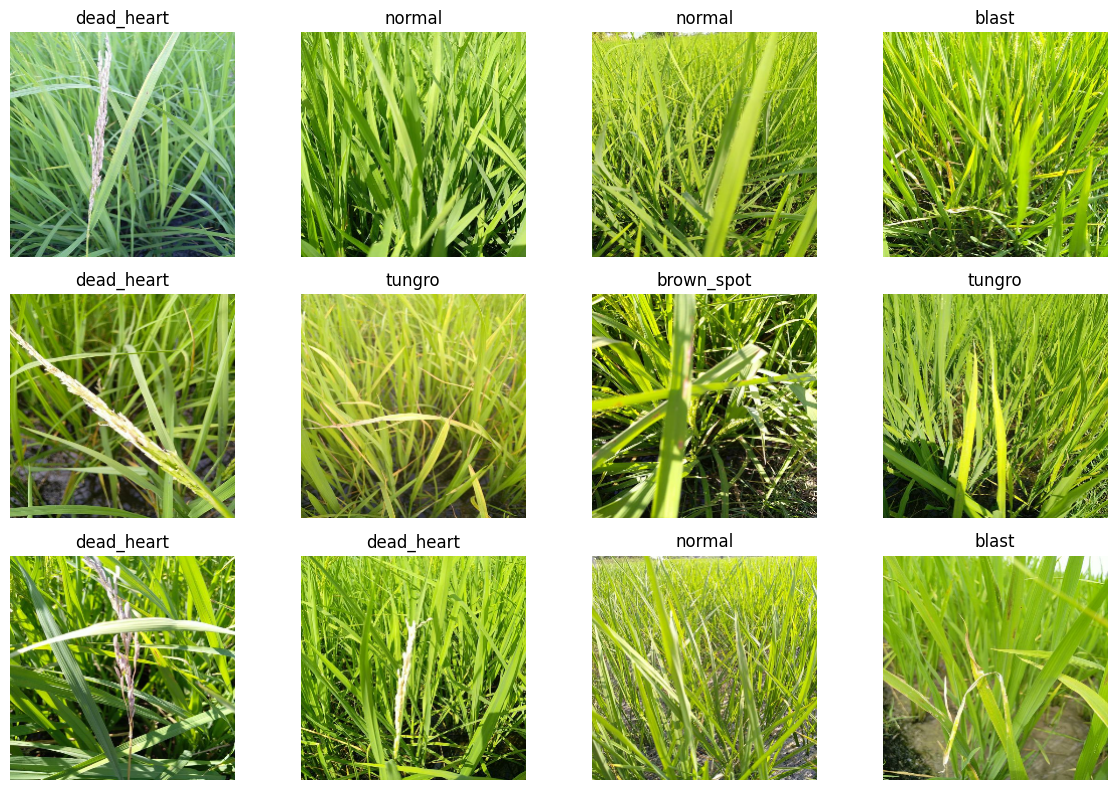

In [39]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 8))

    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)

        # Convert MobileNetV2 preprocessed image [-1, 1]
        # back to [0, 1] only for displaying
        display_image = (images[i].numpy() + 1.0) / 2.0
        display_image = display_image.clip(0, 1)

        plt.imshow(display_image)
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [40]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

def load_and_preprocess_effnet(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label

In [41]:
def make_effnet_dataset(dataframe, training=False):
    paths = dataframe["filepath"].values
    labels = dataframe["label"].map(class_to_index).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    ds = ds.map(
        load_and_preprocess_effnet,
        num_parallel_calls=2
    )

    if training:
        ds = ds.shuffle(
            buffer_size=2048,
            seed=SEED
        )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(1)

    return ds

eff_train_ds = make_effnet_dataset(train_df, training=True)
eff_val_ds = make_effnet_dataset(val_df)
eff_test_ds = make_effnet_dataset(test_df)

print("EfficientNet datasets ready!")

EfficientNet datasets ready!


In [42]:
for images, labels in eff_train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Pixel range: 0.0 to 255.0


In [43]:
eff_data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="effnet_data_augmentation")

In [44]:
eff_base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

eff_base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [45]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = eff_data_augmentation(inputs)

x = eff_base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

eff_model = tf.keras.Model(inputs, outputs)

In [46]:
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

eff_model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ effnet_data_augmentation        │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [47]:
eff_checkpoint = "/content/drive/MyDrive/FarmSight/models/best_paddy_effnet_stage1.keras"

eff_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        eff_checkpoint,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6
    )
]

In [48]:
eff_history = eff_model.fit(
    eff_train_ds,
    validation_data=eff_val_ds,
    epochs=10,
    callbacks=eff_callbacks
)

Epoch 1/10
455/456 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3320 - loss: 1.8953
Epoch 1: val_loss improved from None to 1.39573, saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_effnet_stage1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_effnet_stage1.keras
456/456 ━━━━━━━━━━━━━━━━━━━━ 54s 79ms/step - accuracy: 0.4141 - loss: 1.6981 - val_accuracy: 0.5106 - val_loss: 1.3957 - learning_rate: 0.0010
Epoch 2/10
455/456 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5029 - loss: 1.4253
Epoch 2: val_loss improved from 1.39573 to 1.25430, saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_effnet_stage1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_effnet_stage1.keras
456/456 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.5205 - loss: 1.3990 - val_accuracy: 0.5714 - val_loss: 1.2543 - learning_rate: 0.0010
Epoch 3/10
455/456 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step 

In [49]:
eff_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/FarmSight/models/best_paddy_effnet_stage1.keras"
)

print("Best EfficientNet Stage-1 model loaded!")

Best EfficientNet Stage-1 model loaded!


In [50]:
eff_base_model = eff_model.get_layer("efficientnetb0")

eff_base_model.trainable = True

for layer in eff_base_model.layers[:-30]:
    layer.trainable = False

print("Total EfficientNet layers:", len(eff_base_model.layers))
print(
    "Trainable EfficientNet layers:",
    sum(layer.trainable for layer in eff_base_model.layers)
)

Total EfficientNet layers: 238
Trainable EfficientNet layers: 30


In [51]:
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [52]:
eff_finetune_path = (
    "/content/drive/MyDrive/FarmSight/models/"
    "best_paddy_effnet_finetuned.keras"
)

eff_finetune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        eff_finetune_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )
]

In [53]:
eff_finetune_history = eff_model.fit(
    eff_train_ds,
    validation_data=eff_val_ds,
    epochs=5,
    callbacks=eff_finetune_callbacks
)

Epoch 1/5
455/456 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4111 - loss: 1.7848
Epoch 1: val_loss improved from None to 1.24827, saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_effnet_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_effnet_finetuned.keras
456/456 ━━━━━━━━━━━━━━━━━━━━ 58s 87ms/step - accuracy: 0.4470 - loss: 1.6478 - val_accuracy: 0.5919 - val_loss: 1.2483 - learning_rate: 1.0000e-05
Epoch 2/5
455/456 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5277 - loss: 1.3750
Epoch 2: val_loss improved from 1.24827 to 1.11875, saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_effnet_finetuned.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_effnet_finetuned.keras
456/456 ━━━━━━━━━━━━━━━━━━━━ 46s 92ms/step - accuracy: 0.5331 - loss: 1.3607 - val_accuracy: 0.6310 - val_loss: 1.1187 - learning_rate: 1.0000e-05
Epoch 3/5
455/456 ━━━━━━━━━━━━━━━━━

In [54]:
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [55]:
eff_more_history = eff_model.fit(
    eff_train_ds,
    validation_data=eff_val_ds,
    epochs=3,
    callbacks=eff_finetune_callbacks
)

Epoch 1/3
455/456 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6449 - loss: 1.0608
Epoch 1: val_loss improved from 0.93292 to 0.91055, saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_effnet_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_effnet_finetuned.keras
456/456 ━━━━━━━━━━━━━━━━━━━━ 63s 97ms/step - accuracy: 0.6406 - loss: 1.0740 - val_accuracy: 0.6951 - val_loss: 0.9105 - learning_rate: 5.0000e-06
Epoch 2/3
456/456 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6625 - loss: 1.0244
Epoch 2: val_loss improved from 0.91055 to 0.88879, saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_effnet_finetuned.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FarmSight/models/best_paddy_effnet_finetuned.keras
456/456 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step - accuracy: 0.6505 - loss: 1.0475 - val_accuracy: 0.7028 - val_loss: 0.8888 - learning_rate: 5.0000e-06
Epoch 3/3
455/456 ━━━━━━━━━━━━━━

In [56]:
final_eff_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/FarmSight/models/best_paddy_effnet_finetuned.keras"
)

print("Final EfficientNet Paddy model loaded!")

Final EfficientNet Paddy model loaded!


In [57]:
eff_test_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [58]:
eff_test_loss, eff_test_accuracy = final_eff_model.evaluate(
    eff_test_ds
)

print("EfficientNet Test Loss:", eff_test_loss)
print("EfficientNet Test Accuracy:", eff_test_accuracy)

98/98 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.7145 - loss: 0.8666
EfficientNet Test Loss: 0.8666311502456665
EfficientNet Test Accuracy: 0.7144686579704285


In [59]:
import numpy as np

eff_y_true = []
eff_y_pred = []

for images, labels in eff_test_ds:
    predictions = final_eff_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    eff_y_true.extend(labels.numpy())
    eff_y_pred.extend(predicted_classes)

eff_y_true = np.array(eff_y_true)
eff_y_pred = np.array(eff_y_pred)

print("Predictions completed!")
print("Test samples:", len(eff_y_true))

Predictions completed!
Test samples: 1562


In [60]:
from sklearn.metrics import classification_report

print(
    classification_report(
        eff_y_true,
        eff_y_pred,
        target_names=class_names,
        digits=4
    )
)

                          precision    recall  f1-score   support

   bacterial_leaf_blight     0.5634    0.5556    0.5594        72
   bacterial_leaf_streak     0.6400    0.5614    0.5981        57
bacterial_panicle_blight     0.8438    0.5400    0.6585        50
                   blast     0.6699    0.7931    0.7263       261
              brown_spot     0.6804    0.4552    0.5455       145
              dead_heart     0.9269    0.9355    0.9312       217
            downy_mildew     0.6173    0.5376    0.5747        93
                   hispa     0.6429    0.7155    0.6772       239
                  normal     0.7637    0.8415    0.8007       265
                  tungro     0.6690    0.5951    0.6299       163

                accuracy                         0.7145      1562
               macro avg     0.7017    0.6530    0.6702      1562
            weighted avg     0.7147    0.7145    0.7095      1562



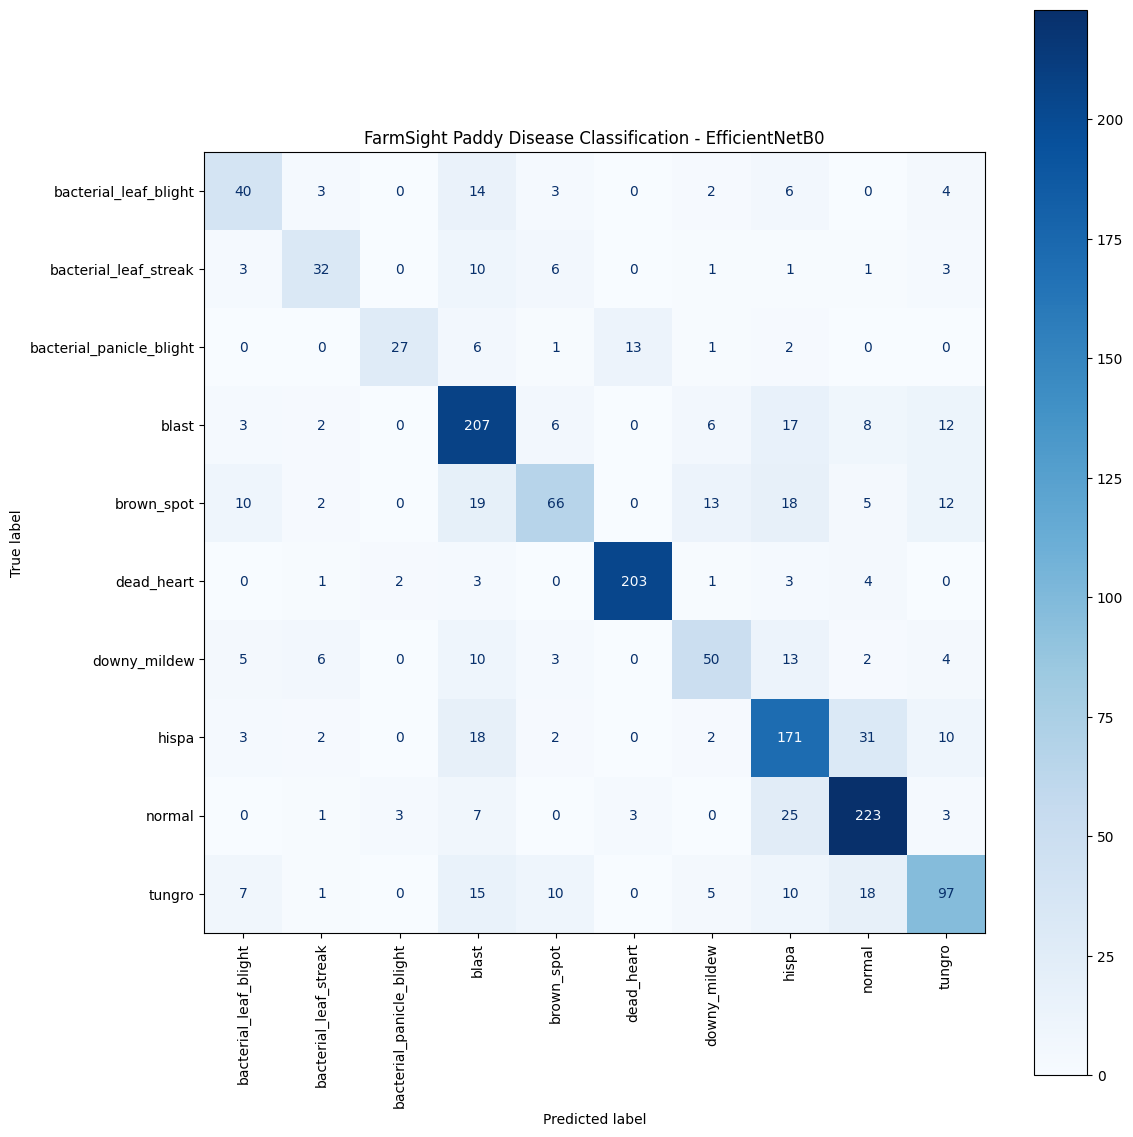

In [61]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(eff_y_true, eff_y_pred)

fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    values_format="d"
)

plt.title("FarmSight Paddy Disease Classification - EfficientNetB0")
plt.tight_layout()
plt.show()

In [62]:
import json

class_mapping_path = "/content/drive/MyDrive/FarmSight/models/paddy_class_names.json"

with open(class_mapping_path, "w") as f:
    json.dump(class_names, f, indent=4)

print("Class mapping saved!")
print(class_mapping_path)

Class mapping saved!
/content/drive/MyDrive/FarmSight/models/paddy_class_names.json


In [63]:
import shutil

source = "/content/drive/MyDrive/FarmSight/models/best_paddy_effnet_finetuned.keras"
destination = "/content/drive/MyDrive/FarmSight/models/paddy_disease_model.keras"

shutil.copy2(source, destination)

print("Final Paddy model created!")
print(destination)

Final Paddy model created!
/content/drive/MyDrive/FarmSight/models/paddy_disease_model.keras
